In [13]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("/kaggle/input/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/Base.csv")

In [15]:
print("Shape of the data:", df.shape)
print("Dataset:", df.sample(5))

Shape of the data: (1000000, 32)
Dataset:         fraud_bool  income  name_email_similarity  prev_address_months_count  \
721599           0     0.9               0.824725                         -1   
58412            0     0.4               0.769027                         28   
918196           0     0.9               0.892105                         -1   
361374           0     0.4               0.318504                         -1   
934453           0     0.9               0.794814                         98   

        current_address_months_count  customer_age  days_since_request  \
721599                           187            40            0.002700   
58412                              4            50            0.004953   
918196                            98            50            0.010186   
361374                            66            30            7.963932   
934453                             3            20            0.024169   

        intended_balcon_amount p

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [17]:
df.isnull().sum()

fraud_bool                          0
income                              0
name_email_similarity               0
prev_address_months_count           0
current_address_months_count        0
customer_age                        0
days_since_request                  0
intended_balcon_amount              0
payment_type                        0
zip_count_4w                        0
velocity_6h                         0
velocity_24h                        0
velocity_4w                         0
bank_branch_count_8w                0
date_of_birth_distinct_emails_4w    0
employment_status                   0
credit_risk_score                   0
email_is_free                       0
housing_status                      0
phone_home_valid                    0
phone_mobile_valid                  0
bank_months_count                   0
has_other_cards                     0
proposed_credit_limit               0
foreign_request                     0
source                              0
session_leng

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fraud_bool,1000000.0,0.011029,0.104438,0.000000e+00,0.000000,0.000000,0.000000,1.000000
income,1000000.0,0.562696,0.290343,1.000000e-01,0.300000,0.600000,0.800000,0.900000
name_email_similarity,1000000.0,0.493694,0.289125,1.434550e-06,0.225216,0.492153,0.755567,0.999999
prev_address_months_count,1000000.0,16.718568,44.046230,-1.000000e+00,-1.000000,-1.000000,12.000000,383.000000
current_address_months_count,1000000.0,86.587867,88.406599,-1.000000e+00,19.000000,52.000000,130.000000,428.000000
customer_age,1000000.0,33.689080,12.025799,1.000000e+01,20.000000,30.000000,40.000000,90.000000
days_since_request,1000000.0,1.025705,5.381835,4.036860e-09,0.007193,0.015176,0.026331,78.456904
intended_balcon_amount,1000000.0,8.661499,20.236155,-1.553055e+01,-1.181488,-0.830507,4.984176,112.956928
zip_count_4w,1000000.0,1572.692049,1005.374565,1.000000e+00,894.000000,1263.000000,1944.000000,6700.000000
velocity_6h,1000000.0,5665.296605,3009.380665,-1.706031e+02,3436.365848,5319.769349,7680.717827,16715.565404


In [20]:
df.nunique()

fraud_bool                               2
income                                   9
name_email_similarity               998861
prev_address_months_count              374
current_address_months_count           423
customer_age                             9
days_since_request                  989330
intended_balcon_amount              994971
payment_type                             5
zip_count_4w                          6306
velocity_6h                         998687
velocity_24h                        998940
velocity_4w                         998318
bank_branch_count_8w                  2326
date_of_birth_distinct_emails_4w        40
employment_status                        7
credit_risk_score                      551
email_is_free                            2
housing_status                           7
phone_home_valid                         2
phone_mobile_valid                       2
bank_months_count                       33
has_other_cards                          2
proposed_cr

In [21]:
# Remove "device_fraud_count", it's 0 for all entries
print(df['device_fraud_count'].value_counts()) # It's 0 for all rows
df = df.drop(['device_fraud_count'], axis=1, errors='ignore') 

device_fraud_count
0    1000000
Name: count, dtype: int64


In [22]:
df.shape

(1000000, 31)

In [23]:
# A summary of statistical information for each non-numerical column in the DataFrame
df.describe(include=["object", "bool"]).transpose()

,count,unique,top,freq
payment_type,1000000,5,AB,370554
employment_status,1000000,7,CA,730252
housing_status,1000000,7,BC,372143
source,1000000,2,INTERNET,992952
device_os,1000000,5,other,342728


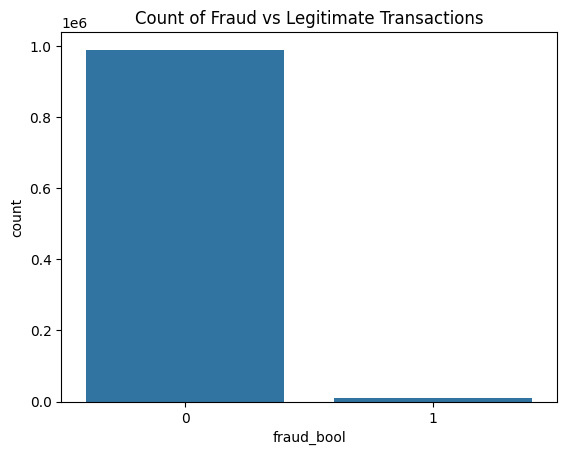

In [24]:
sns.countplot(x='fraud_bool', data=df)
plt.title('Count of Fraud vs Legitimate Transactions')
plt.show()

In [25]:
df['fraud_bool'].value_counts(normalize=True) * 100

fraud_bool
0    98.8971
1     1.1029
Name: proportion, dtype: float64

**Observation:**

The graph of the binary target feature reveals a highly imbalanced distribution, characterised by an extremely low prevalence of the positive class.

## Univariate Analysis

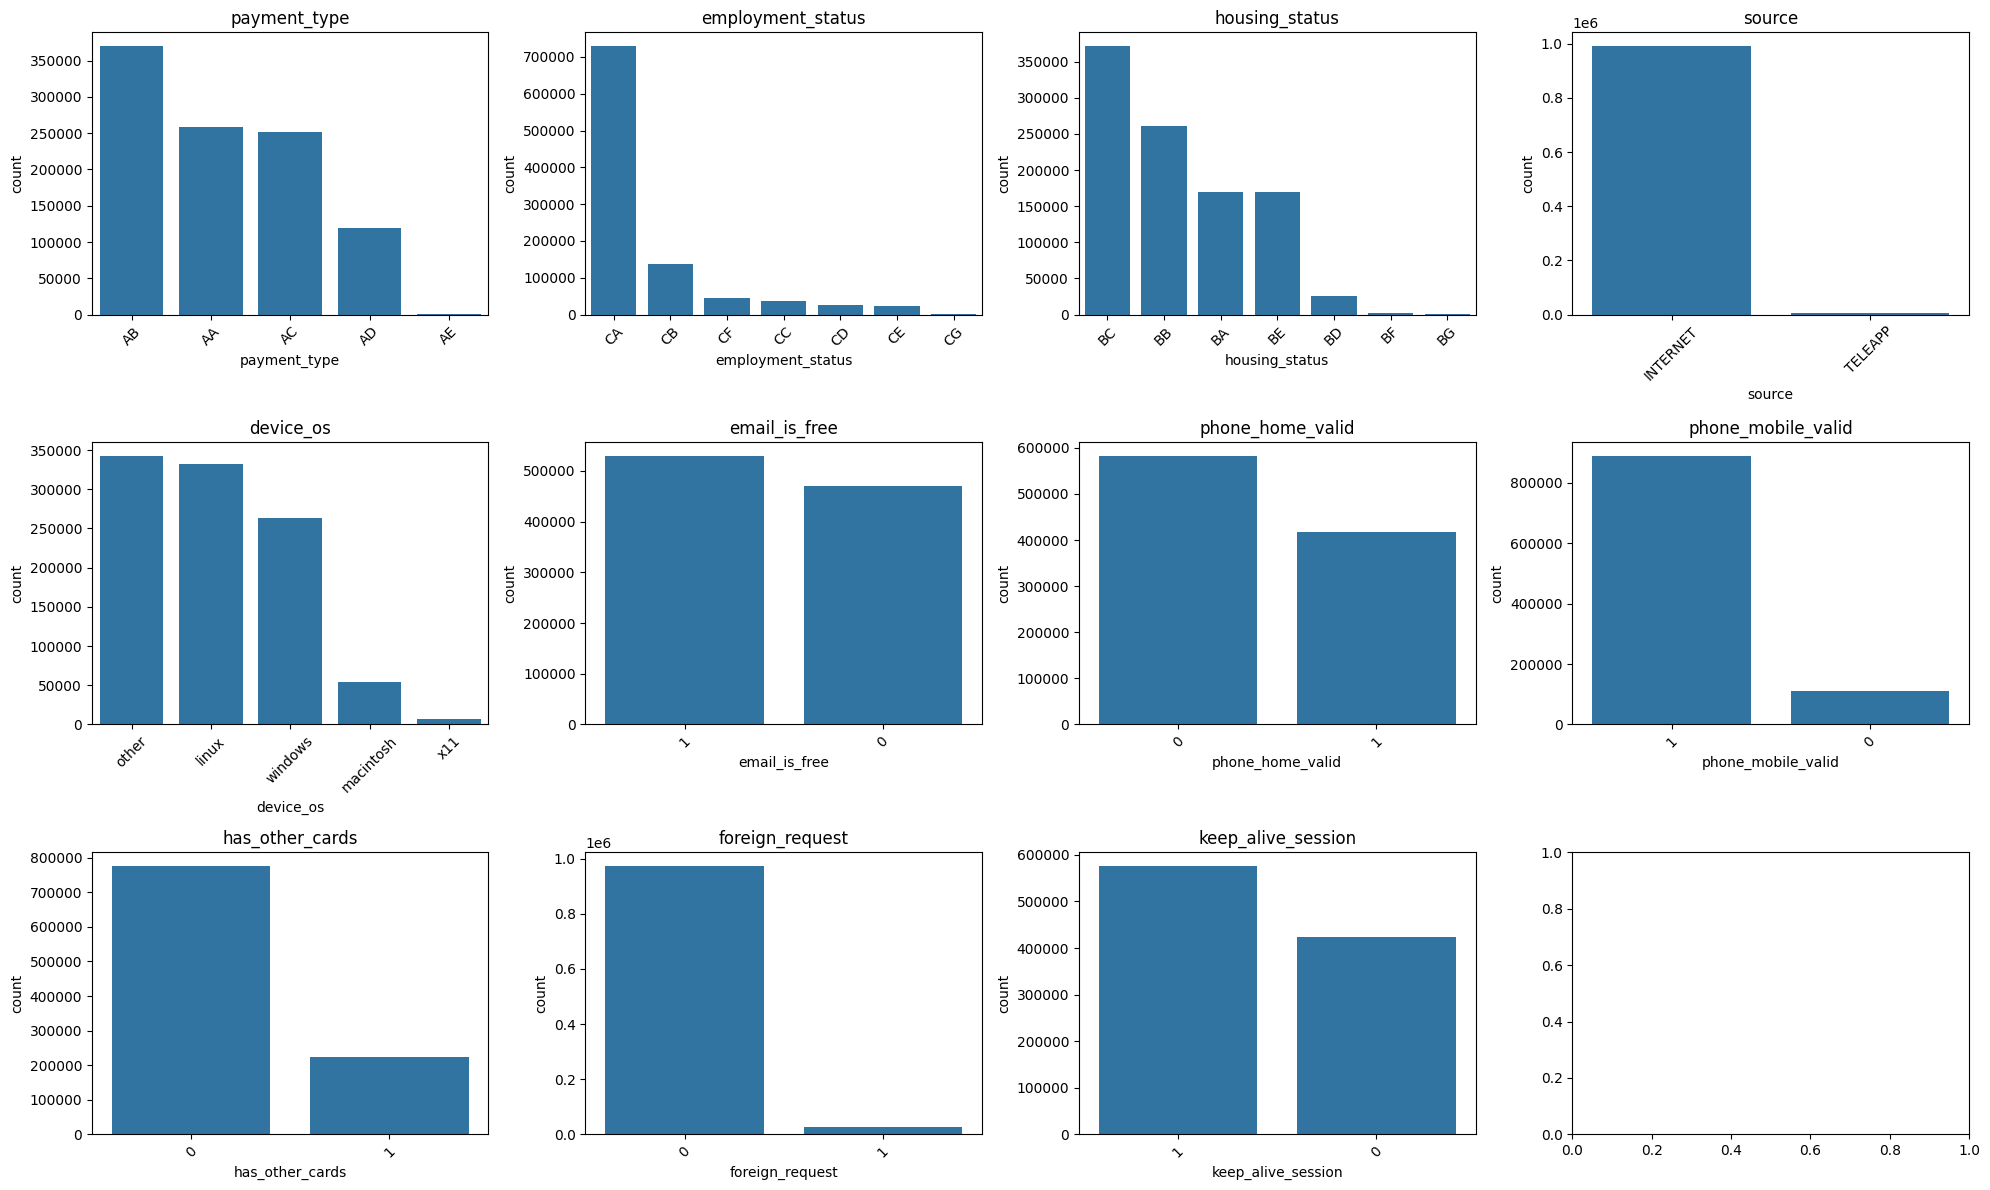

In [26]:
categorical_cols = [
    'payment_type', 'employment_status', 'housing_status', 'source', 'device_os',
    'email_is_free', 'phone_home_valid', 'phone_mobile_valid', 'has_other_cards',
    'foreign_request', 'keep_alive_session'
]

target = 'fraud_bool'

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observation:**

Here we see that the payment type through AE has a very small percentage, which is only 0.029%. Also most of the people send the application through internet and only 0.70% of applications are sent through teleapp. 22.3% of the applicants have other cards. 2.52% of the applicant's applications have been originated from foreign location.

Very few people has asked for foreign_request. The %age of people having other cards is less.


We have ~19 more numerical columns, each with 10 lakh rows. Two separate problems show up here:

Speed/memory: drawing a histogram of 10 lakh individual points takes meaningfully longer and uses more memory than drawing one from 50,000 points.

Fraud is rare — so if we took a plain random 5% sample, we risk ending up with very few or even zero fraud rows in that sample, especially for plots later that split by fraud_bool. To avoid that, we take 5% from each class separately (this is called stratified sampling) so both legitimate and fraud rows stay proportionally represented.

In [27]:
# Stratified sample: keep 5% of legitimate rows AND 5% of fraud rows separately
df_sample = df.groupby('fraud_bool', group_keys=False).apply(
    lambda x: x.sample(frac=0.05, random_state=42)
)

print("Full dataset:", df.shape)
print("Sample for plotting:", df_sample.shape)
print("\nFraud % in full data:   ", round(df['fraud_bool'].mean() * 100, 3))
print("Fraud % in sample:      ", round(df_sample['fraud_bool'].mean() * 100, 3))

Full dataset: (1000000, 31)
Sample for plotting: (50000, 31)

Fraud % in full data:    1.103
Fraud % in sample:       1.102


/tmp/ipykernel_58/1771898892.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('fraud_bool', group_keys=False).apply(


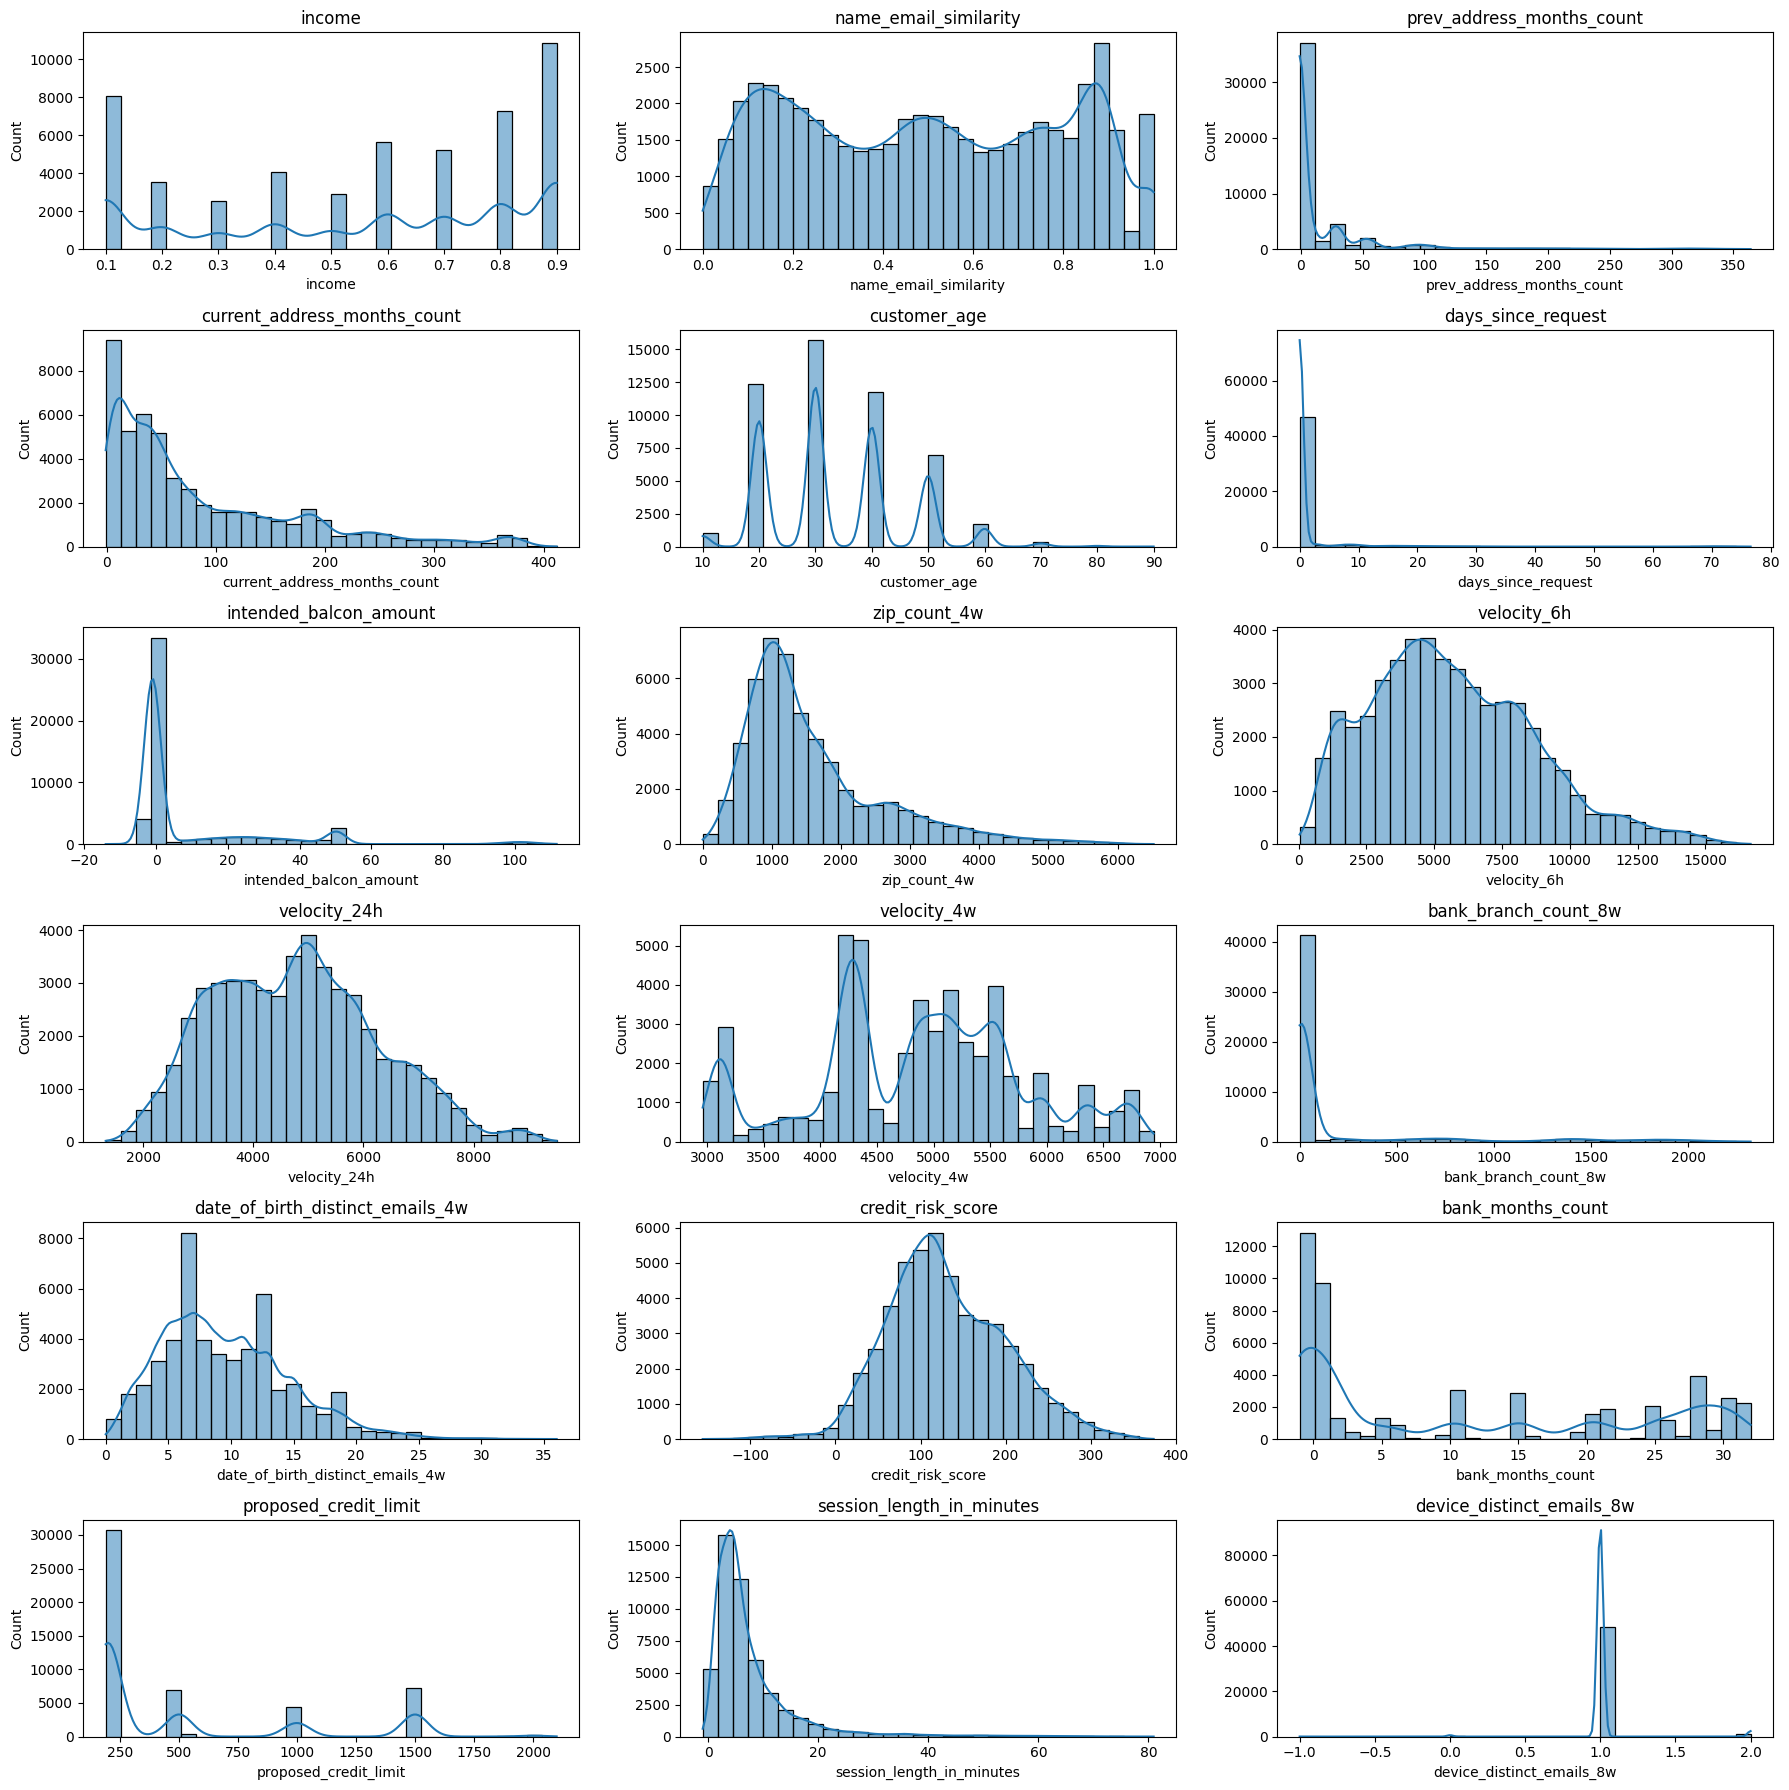

In [28]:
numerical_cols = [
    'income', 'name_email_similarity', 'prev_address_months_count',
    'current_address_months_count', 'customer_age', 'days_since_request',
    'intended_balcon_amount', 'zip_count_4w', 'velocity_6h', 'velocity_24h',
    'velocity_4w', 'bank_branch_count_8w', 'date_of_birth_distinct_emails_4w',
    'credit_risk_score', 'bank_months_count', 'proposed_credit_limit',
    'session_length_in_minutes', 'device_distinct_emails_8w'
]

fig, axes = plt.subplots(6, 3, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df_sample[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Bivariate Analysis 

### Numerical column vs Target

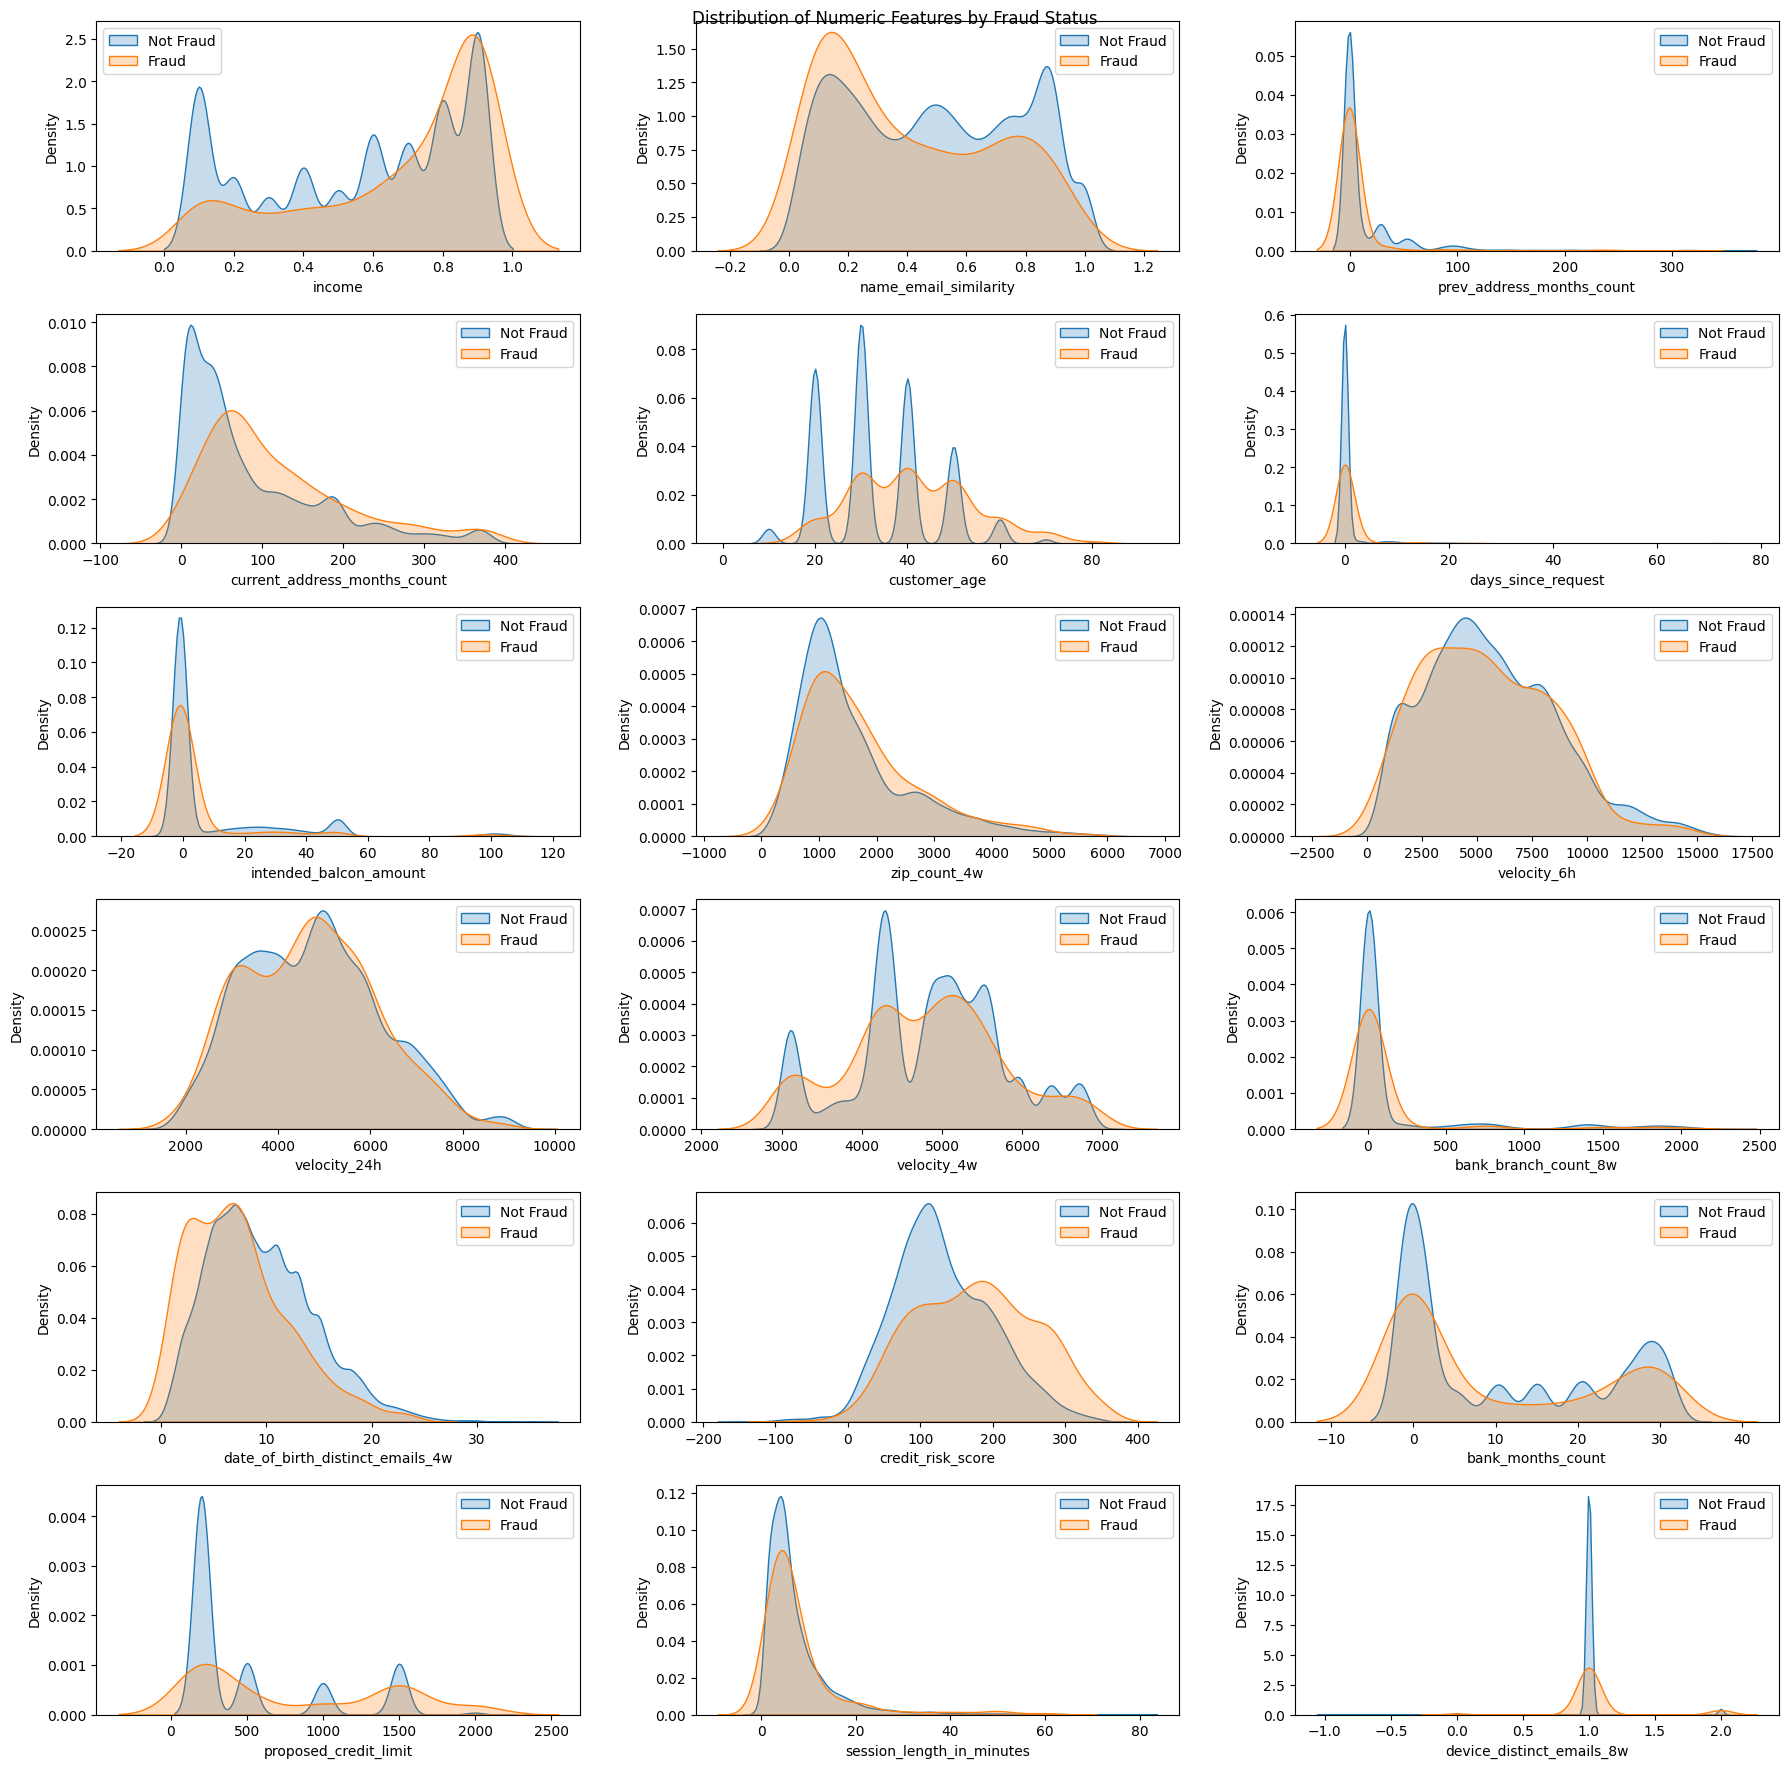

In [29]:
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 18))

fig.suptitle('Distribution of Numeric Features by Fraud Status')

# Loop through the numeric features and plot a kernel density plot for each feature
for i, feature in enumerate(numerical_cols):
    ax = axes[i // 3][i % 3]
    sns.kdeplot(data=df_sample[df_sample['fraud_bool'] == 0][feature], fill=True, ax=ax, label='Not Fraud')
    sns.kdeplot(data=df_sample[df_sample['fraud_bool'] == 1][feature], fill=True, ax=ax, label='Fraud')
    ax.set_xlabel(feature)
    ax.legend()

plt.tight_layout()
plt.show()

In [30]:
my_palette = sns.color_palette("husl", 2)
sns.set_style("whitegrid")

/tmp/ipykernel_58/419856219.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='fraud_bool', y=feature, ax=ax, palette = my_palette, boxprops=dict(alpha=.6))
/tmp/ipykernel_58/419856219.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Fraud', 'Fraud'])
/tmp/ipykernel_58/419856219.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='fraud_bool', y=feature, ax=ax, palette = my_palette, boxprops=dict(alpha=.6))
/tmp/ipykernel_58/419856219.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

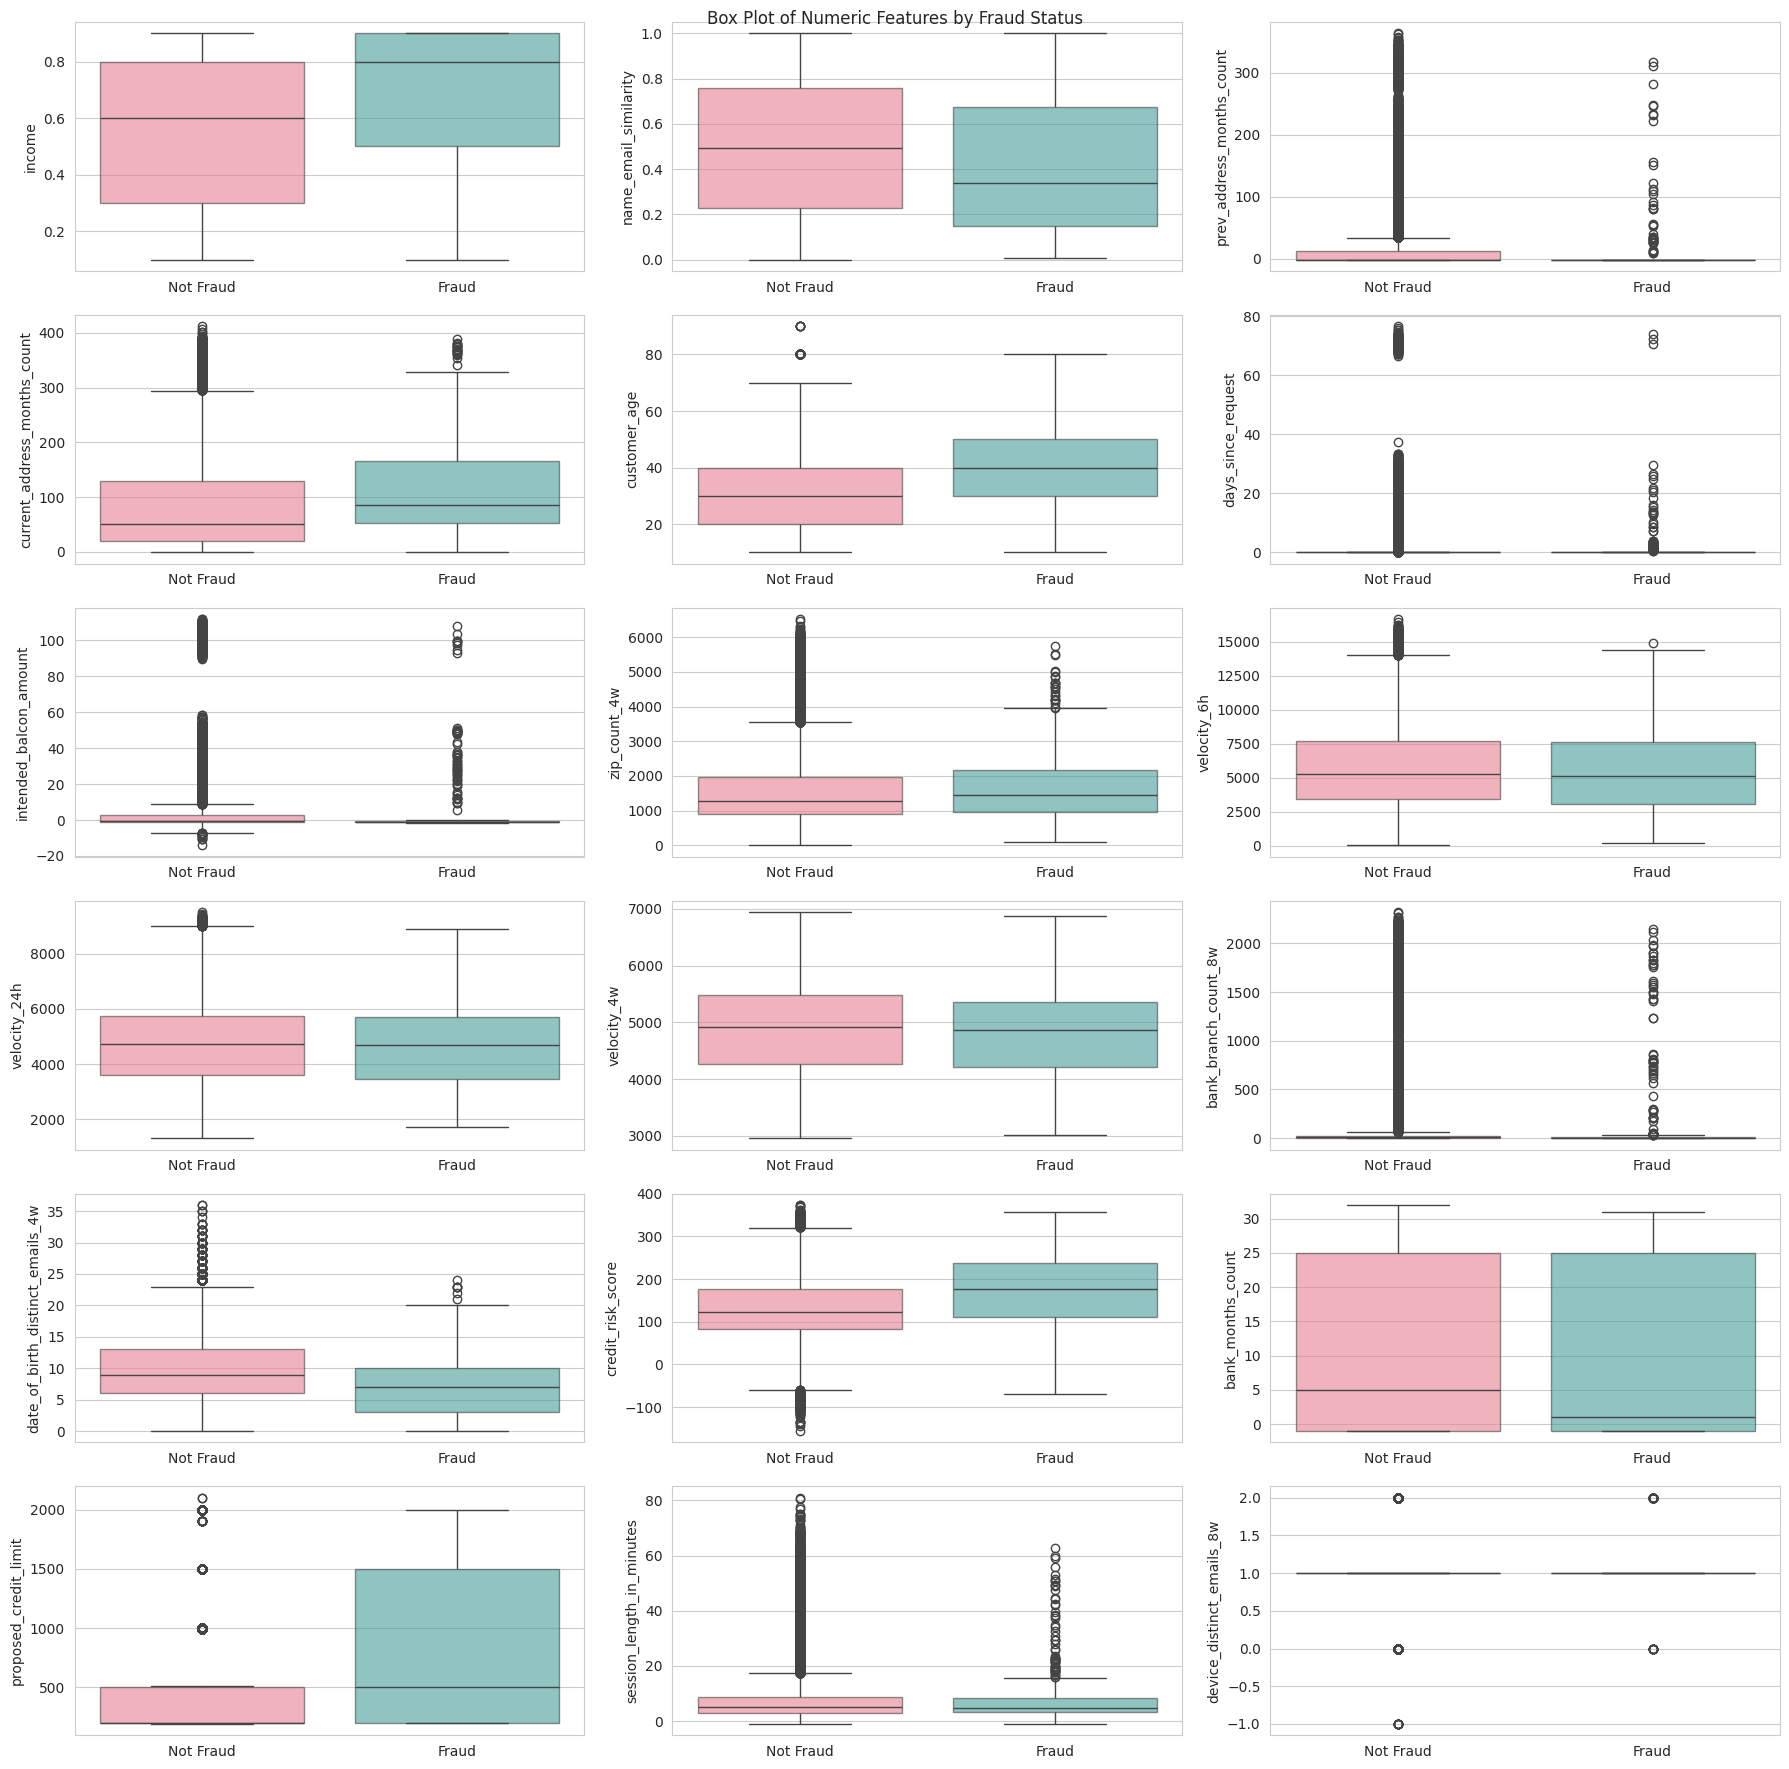

In [31]:
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 18))

fig.suptitle('Box Plot of Numeric Features by Fraud Status')

# Loop through the numeric features and plot a box plot for each feature
for i, feature in enumerate(numerical_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df_sample, x='fraud_bool', y=feature, ax=ax, palette = my_palette, boxprops=dict(alpha=.6))
    ax.set_xlabel('')
    ax.set_ylabel(feature)
    ax.set_xticklabels(['Not Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

### Categorical column vs Target

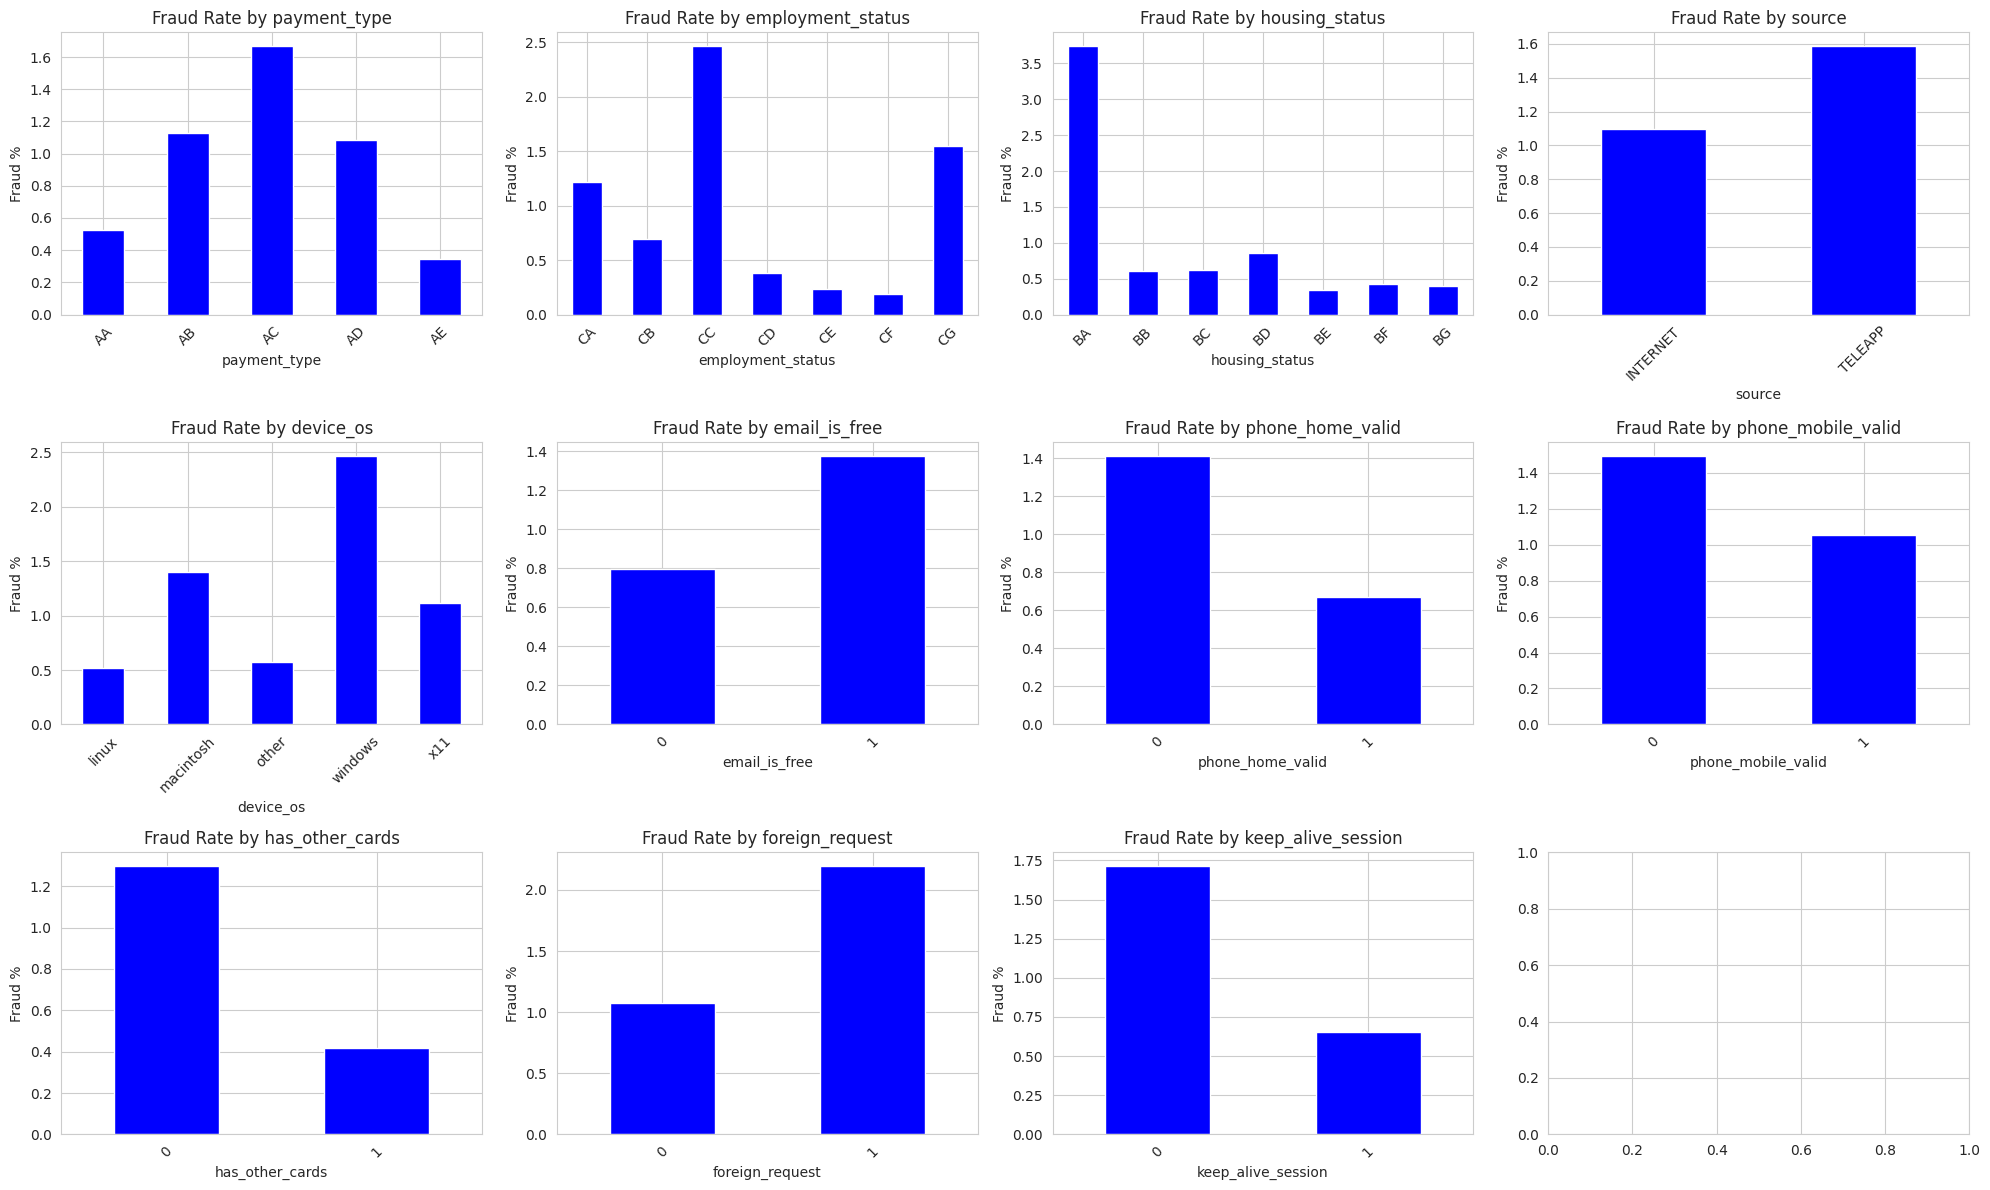

In [32]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    fraud_rate = df.groupby(col)[target].mean() * 100
    fraud_rate.plot(kind='bar', ax=axes[i], color='blue')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud %')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Multivariate Analysis 

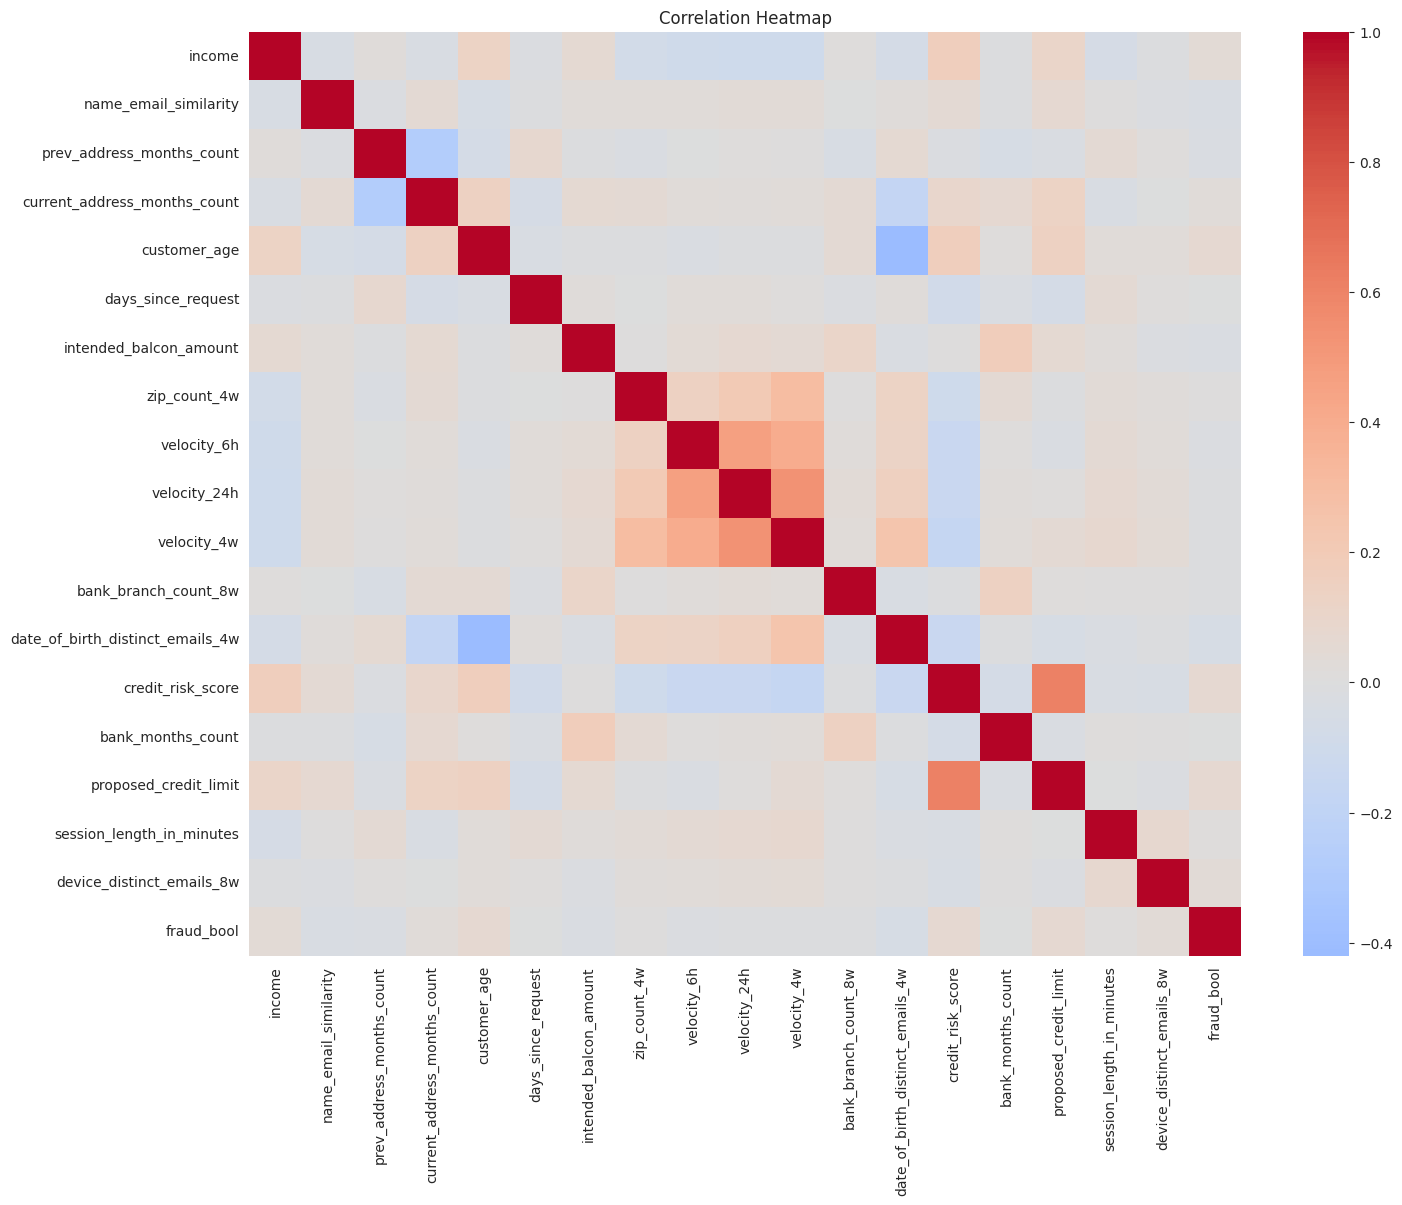

Correlation of each feature with fraud_bool, sorted:

fraud_bool                          1.000000
credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
income                              0.045079
device_distinct_emails_8w           0.035704
current_address_months_count        0.033701
session_length_in_minutes           0.008999
zip_count_4w                        0.005212
days_since_request                  0.000567
bank_months_count                  -0.003222
velocity_24h                       -0.011183
velocity_4w                        -0.011536
bank_branch_count_8w               -0.011577
velocity_6h                        -0.016892
intended_balcon_amount             -0.024524
prev_address_months_count          -0.026031
name_email_similarity              -0.036720
date_of_birth_distinct_emails_4w   -0.043224
Name: fraud_bool, dtype: float64


In [33]:
plt.figure(figsize=(16, 12))
corr_matrix = df[numerical_cols + [target]].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print("Correlation of each feature with fraud_bool, sorted:\n")
print(corr_matrix[target].sort_values(ascending=False))

**Observation:**

1. Correlation measures linear relationships only.
2. A feature with a low correlation can still be highly important in models like Random Forest, XGBoost, or Decision Trees, because they capture non-linear relationships and interactions between variables.

3. Last row tells how each feature is linearly related to fraud. The following columns: 
credit_risk_score                   0.070624
proposed_credit_limit               0.068907
customer_age                        0.062959
income                              0.045079
device_distinct_emails_8w           0.035704
current_address_months_count        0.033701
appears to have small positive correlation with fraud. 
These variables have only a weak linear relationship with fraud. They may still be useful when combined with other variables in machine learning models.

4. We can clearly see a dark orange block among velocity_6h, velocity_24h and velocity_4w
This means these variables are positively correlated.
Interpretation: 
These variables measure application activity over different time windows.

5. These two variables show a noticeable positive correlation. Because banks usually give larger credit limits to applicants with higher credit scores.

6. Current Address & Previous Address Months
These two variables show a moderate negative correlation.

7. Customer Age & Date of Birth Distinct Emails
There is a moderate negative correlation.
This may indicate that younger customers tend to have more distinct email usage patterns, while older customers tend to have fewer.

#### Visualising several top features together 

Top 4 features most correlated with fraud_bool: ['credit_risk_score', 'proposed_credit_limit', 'customer_age', 'income']


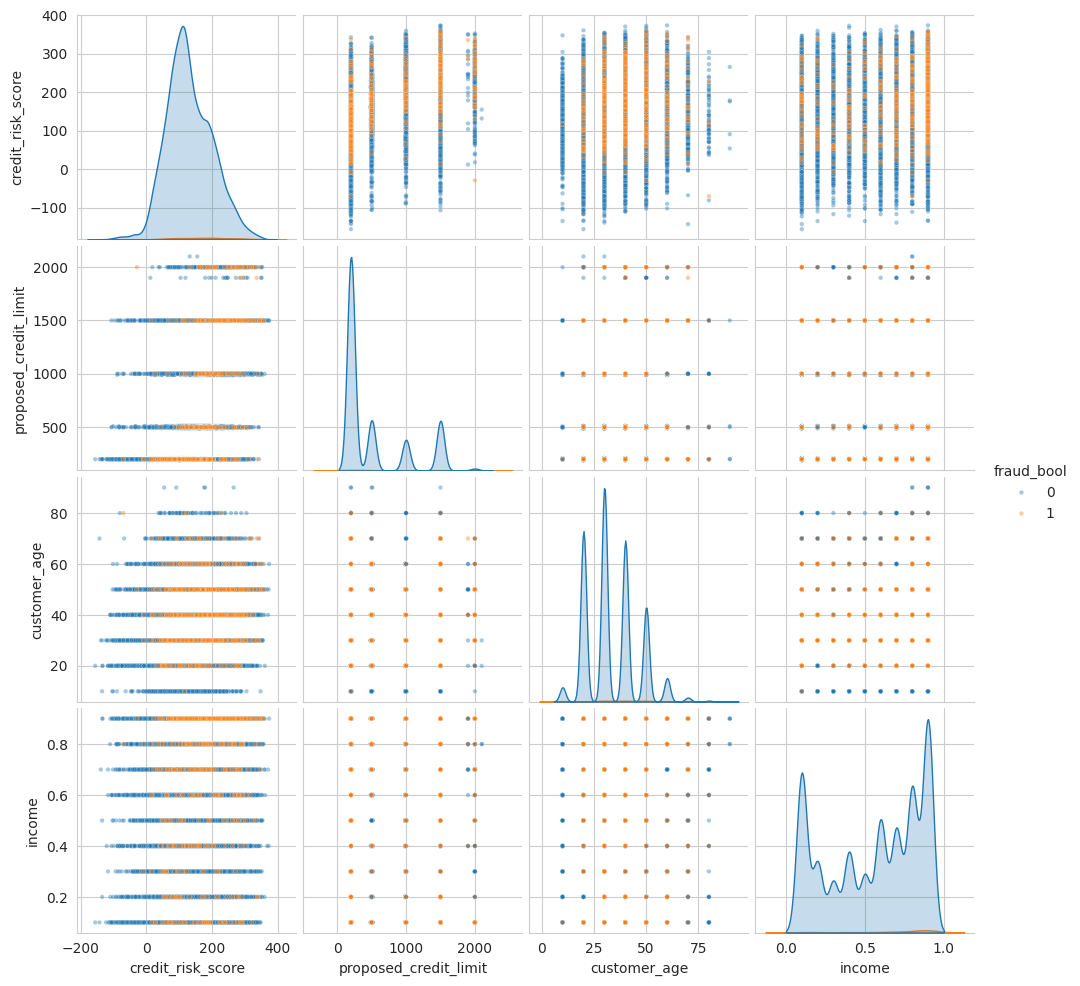

In [34]:
top_features = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(4).index.tolist()
print("Top 4 features most correlated with fraud_bool:", top_features)

sns.pairplot(df_sample, vars=top_features, hue=target, plot_kws={'alpha': 0.4, 's': 10})
plt.show()

### Fraud rate over time 

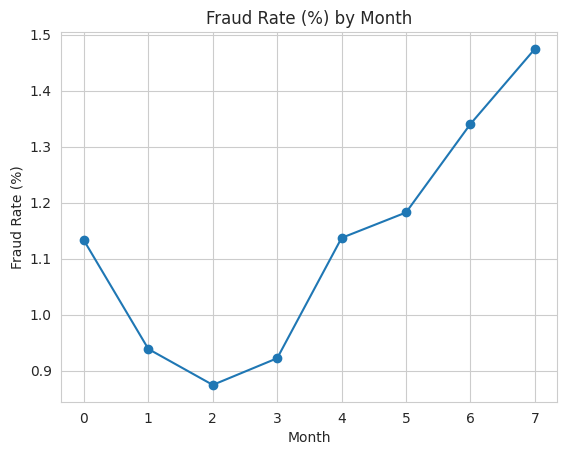

month
0    1.132588
1    0.938724
2    0.874587
3    0.922245
4    1.137120
5    1.182505
6    1.340507
7    1.474552
Name: fraud_bool, dtype: float64


In [35]:
monthly_fraud_rate = df.groupby('month')[target].mean() * 100

monthly_fraud_rate.plot(kind='line', marker='o')
plt.title('Fraud Rate (%) by Month')
plt.xlabel('Month')
plt.ylabel('Fraud Rate (%)')
plt.show()

print(monthly_fraud_rate)

## One Hot Encoding

In [36]:
nominal_cols = ['payment_type', 'employment_status', 'housing_status', 'device_os', 'source']

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape before encoding: (1000000, 31)
Shape after encoding: (1000000, 47)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BC,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,device_os_macintosh,device_os_other,device_os_windows,device_os_x11,source_TELEAPP
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,1059,13096.035018,...,True,False,False,False,False,False,False,False,False,False
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,1658,9223.283431,...,True,False,False,False,False,False,True,False,False,False
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,1095,4471.472149,...,True,False,False,False,False,False,False,True,False,False
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,3483,14431.993621,...,True,False,False,False,False,False,False,False,False,False
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,2339,7601.511579,...,True,False,False,False,False,False,True,False,False,False


## Skewness

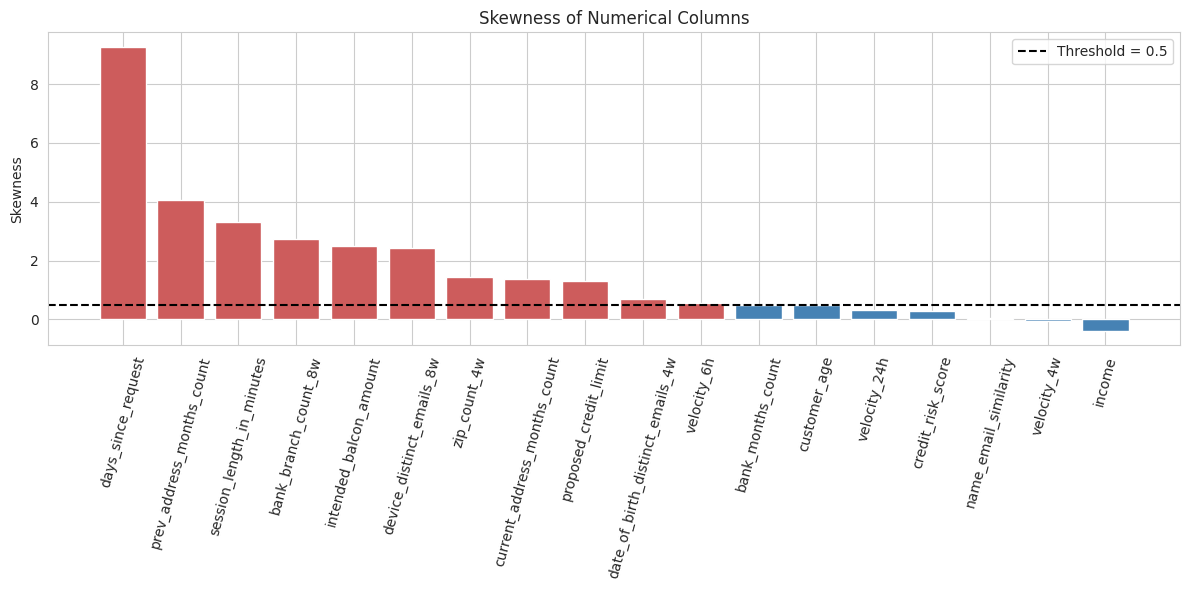

days_since_request                  9.278955
prev_address_months_count           4.063888
session_length_in_minutes           3.304575
bank_branch_count_8w                2.747161
intended_balcon_amount              2.507173
device_distinct_emails_8w           2.430764
zip_count_4w                        1.456657
current_address_months_count        1.386998
proposed_credit_limit               1.301410
date_of_birth_distinct_emails_4w    0.703250
velocity_6h                         0.562682
bank_months_count                   0.488747
customer_age                        0.478079
velocity_24h                        0.331134
credit_risk_score                   0.295895
name_email_similarity               0.042839
velocity_4w                        -0.060125
income                             -0.386337
dtype: float64


In [37]:
# Compute skewness for every numerical column
skewness = df[numerical_cols].skew().sort_values(ascending=False)

# Threshold choice: 0.5 is a standard statistical convention (Bulmer's rule) —
# |skew| < 0.5 is considered fairly symmetric, beyond that it's skewed.
# We're checking the signed value here (not absolute), since we specifically
# want to separate "positively skewed" from everything else.
threshold = 0.5

colors = ['indianred' if val > threshold else 'steelblue' for val in skewness.values]

plt.figure(figsize=(12, 6))
plt.bar(skewness.index, skewness.values, color=colors)
plt.axhline(y=threshold, color='black', linestyle='--', label=f'Threshold = {threshold}')
plt.xticks(rotation=75)
plt.ylabel('Skewness')
plt.title('Skewness of Numerical Columns')
plt.legend()
plt.tight_layout()
plt.show()

print(skewness)

In [38]:
positively_skewed = skewness[skewness > threshold].index.tolist()
not_positively_skewed = skewness[skewness <= threshold].index.tolist()

print("Positively skewed (skew > threshold) — avoid mean imputation, use median instead:")
print(positively_skewed)

print("\nNot positively skewed (skew <= threshold):")
print(not_positively_skewed)

Positively skewed (skew > threshold) — avoid mean imputation, use median instead:
['days_since_request', 'prev_address_months_count', 'session_length_in_minutes', 'bank_branch_count_8w', 'intended_balcon_amount', 'device_distinct_emails_8w', 'zip_count_4w', 'current_address_months_count', 'proposed_credit_limit', 'date_of_birth_distinct_emails_4w', 'velocity_6h']

Not positively skewed (skew <= threshold):
['bank_months_count', 'customer_age', 'velocity_24h', 'credit_risk_score', 'name_email_similarity', 'velocity_4w', 'income']


**Observation:**

Positively skewed variables may require special treatment or transformation (such as log transformation) to address the asymmetry in their distributions before applying certain statistical techniques that assume normality. Alternatively, variables with skewness values below the threshold may not require any special treatment, as their distributions are approximately symmetric

## Handling missing values

In [39]:
minus1_cols = ['prev_address_months_count', 'current_address_months_count',
                        'bank_months_count', 'session_length_in_minutes', 'device_distinct_emails_8w']

print("--- Columns where -1 specifically means missing ---")
for col in minus1_cols:
    pct = (df[col] == -1).mean() * 100
    print(f"{col:35} missing: {pct:.2f}%")

print("\n--- intended_balcon_amount (any negative value = missing) ---")
pct = (df['intended_balcon_amount'] < 0).mean() * 100
print(f"intended_balcon_amount{'':14} missing: {pct:.2f}%")

--- Columns where -1 specifically means missing ---
prev_address_months_count           missing: 71.29%
current_address_months_count        missing: 0.43%
bank_months_count                   missing: 25.36%
session_length_in_minutes           missing: 0.20%
device_distinct_emails_8w           missing: 0.04%

--- intended_balcon_amount (any negative value = missing) ---
intended_balcon_amount               missing: 74.25%
